## importing libraries, loading the data, etc

In [149]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
import seaborn as sns
from tqdm.notebook import tqdm
import os
import itertools
from scipy.stats import kstest, pearsonr, gaussian_kde
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


spath = 'paper_plots_clean'



In [2]:
def filter_imgs_multiple_objects(df):
    # filter out imges with multiple objects in the same image:
    counts = df[['ImageNumber', 'ObjectNumber']].groupby('ImageNumber').agg('count')
    counts.columns=['Count']
    df_incl_counts = df.merge(counts, how='left', left_on='ImageNumber', right_index=True)
    df_filtered = df_incl_counts[df_incl_counts['Count'] == 1]
    return df_filtered

def read_and_filter(filename):
    df_raw = pd.read_csv(filename)
    df_filtered = filter_imgs_multiple_objects(df_raw)
    return df_filtered

In [3]:
print('current working directory:', os.getcwd())
try:
    os.chdir("topochip-flow-matching/cellprofiler validation")
except:
    print("Failed to change directory")
print('current working directory:', os.getcwd())

if not os.path.exists(spath):
    os.makedirs(spath)


current working directory: D:\topochip-flow-matching\cellprofiler validation
Failed to change directory
current working directory: D:\topochip-flow-matching\cellprofiler validation


In [4]:
# define which csv to load:
filename = 'MyExpt_IdentifySecondaryObjects_H_threshold_H_primary.csv'
prefix_real = 'cp_output_archive/cp_output_allreal/'
prefix_fake = 'cp_output_archive/cp_output_allfake/'

path_to_cp_output = prefix_real + filename
second_path_to_cp_output = prefix_fake + filename

paths_to_yap_nucleus = [p + 'MyExpt_YAP_nucleus.csv' for p in [prefix_real, prefix_fake]]
paths_to_yap_cytoplasm = [p + 'MyExpt_YAP_cytoplasm.csv' for p in [prefix_real, prefix_fake]]

paths_to_dapi = [p + 'MyExpt_IdentifyPrimaryObjects_H_threshold.csv' for p in [prefix_real, prefix_fake]]

In [5]:
# read the csvs with pandas:

prefix_real = 'cp_output_archive/cp_output_allreal/'
prefix_fake = 'cp_output_archive/cp_output_allfake/'

filenames = {'dapi': 'MyExpt_IdentifyPrimaryObjects_H_threshold.csv',
            'actin': 'MyExpt_IdentifySecondaryObjects_H_threshold_H_primary.csv',
            'yap_nucleus':'MyExpt_YAP_nucleus.csv',
            'yap_cyto':'MyExpt_YAP_cytoplasm.csv'}

data = {}
for stain, fname in tqdm(filenames.items(), total=len(filenames.keys())):
    dfs = []
    for prefix in [prefix_real, prefix_fake]:
        dfs.append(
            read_and_filter(os.path.join(prefix, fname))
        )
    # concatenate the real and fake dfs to one big df:
    df = pd.DataFrame(
            np.concatenate([df_instance.values for df_instance in dfs], axis=0),
            columns=dfs[0].columns
    )
    data[stain] = df


  0%|          | 0/4 [00:00<?, ?it/s]

In [6]:
# make one big df out of all the small dfs:

full_df = None
stains = ['dapi', 'actin', 'yap_nucleus', 'yap_cyto']

for i, stain in enumerate(stains):
    if full_df is None:
        full_df = data[stain]
    else:
        full_df = pd.merge(left=full_df, right=data[stain], how='inner',
                           left_on=['ImageNumber', 'ObjectNumber', 'Metadata_Source'],
                            right_on=['ImageNumber', 'ObjectNumber','Metadata_Source'], 
                           suffixes=['_' + stains[i-1], '_' + stains[i]],
                               validate='1:1'
                          )
        
assert len(full_df) == len(data['dapi']), 'expected equal number of rows in full df as in dapi and other dfs!'

In [7]:
# add yap nulc_div_cyto feat:
full_df['Intensity_IntegratedIntensity_YAP_yap_nucleus_div_cyto'] = full_df['Intensity_IntegratedIntensity_YAP_yap_nucleus'] / full_df['Intensity_IntegratedIntensity_YAP_yap_cyto'].replace(0, np.nan)

## histograms over relevant cellular properties

In [8]:
def calc_pdfs(datas, cumulative, use_kde=False, **hist_kwargs):
    out = []
    low = min([np.min(data) for data in datas])
    high = max([np.max(data) for data in datas])
    for data in datas:
        if use_kde:
            data = data[~np.isnan(data)]
            kde = gaussian_kde(data)
            x = np.linspace(low, high, num=200)
            y = kde(x)
        else:
            y, binedges = np.histogram(data, **hist_kwargs)
            bincenters = (binedges[1:] + binedges[:-1]) * 0.5
            if cumulative:
                y = np.cumsum(y * np.diff(binedges))
            x, y = bincenters, y
        out.append([x, y])
    return out
    

def make_histograms(df, chips, feats, axs, sources=('real', 'fake'),
                    hist_kwargs=dict(density=True), calc_ks=True, colors=None, markers=None):
    assert axs.shape[0] == len(chips) and axs.shape[1] == len(feats), \
        f'expected shape of axs to align with chips and feats, but got shape, {axs.shape}, chips {len(chips)}, feats {len(feats)}!'
    
    for i, chip in enumerate(chips):  # plot each chip on a new row
        for j, feat in enumerate(feats): # plot each feature in a new column
            ax = axs[i,j]
            all_datas = []
            for k, source in enumerate(sources):
                data = df[df['Metadata_Chip_dapi'] == chip + '_' + source]
                all_datas.append(pd.to_numeric(data[feat]))
#                 ax.hist(data[feat], label=source, 
# #                         histtype='step',
#                         **hist_kwargs)
            pdfs = calc_pdfs(all_datas, **hist_kwargs)
            for k, pdf in enumerate(pdfs):
                c = colors[k] if colors is not None else None
                m = markers[k] if markers is not None else None
                ax.plot(pdf[0], pdf[1], label=sources[k].capitalize(), color=c, marker=m, markersize=10, linewidth=3, linestyle='-', markevery=20, markerfacecolor='none',
                        markeredgewidth=2, )
            if calc_ks:
                assert len(all_datas) == 2, f'expected 2 sources for data but got {len(all_datas)}!'
                ks = kstest(all_datas[0],
                           all_datas[1])
                ax.plot([], [], label=f'KS test - stat: {float(np.round(ks.statistic, 2))}, p: {float(np.round(ks.pvalue, 2))}, n:{all_datas[0].__len__()}')
            # ax.legend(frameon=False)
    # set the column and row labels:
    for ax, col in zip(axs[0], feats):
        lab = col.split('_')[2].capitalize() + ' ' + col.split('_')[1].capitalize()
        ax.set_title(lab)

    for ax, row in zip(axs[:,0], chips):
        lab = 'Surface ' + row.split('_')[1]
        ax.set_ylabel(lab, rotation=90)

    # finally, make one legend for all axes, taking care of an appropriate fontsize:
    handles, labels = axs[0,0].get_legend_handles_labels()
    labels[-1] = 'Generated'
    # handles, labels = list(itertools.zip_longest(*set(zip(handles, labels))))
    fig = axs[0,0].figure
    fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.0))
    fig.tight_layout()
    return
    

In [9]:
full_df.columns[full_df.columns.str.contains('anular')]

Index([], dtype='object')

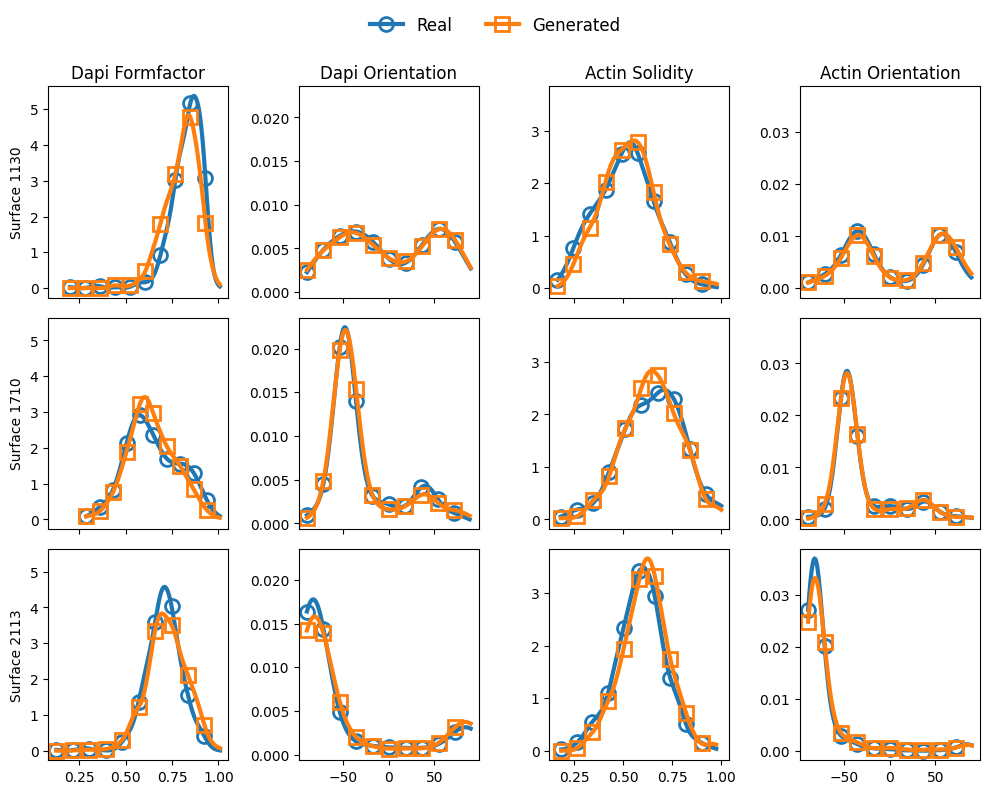

In [10]:
## change here the chips and features you want to plot the distribution of, as well a hist_kwargs
# hist_kwargs can contain cumulative: bool, as well as any kwargs accepted by np.histogram

feats = ['AreaShape_FormFactor_dapi', 'AreaShape_Orientation_dapi','AreaShape_Solidity_actin', 
         'AreaShape_Orientation_actin'
        ] 
chips = ['Chip_1130_1', 'Chip_1710_1', 'Chip_2113_1']
hist_kwargs=dict(density=True, bins=35, cumulative=False, use_kde=True)

# start making the plot
fig, axs = plt.subplots(ncols=len(feats), nrows=len(chips), squeeze=False, figsize=(2.5*len(feats), 2.5*(len(chips))),
                       sharex='col', sharey='col')

make_histograms(full_df, chips, feats, axs, hist_kwargs=hist_kwargs, calc_ks=False, colors=('tab:blue', 'tab:orange'),
                markers=('o', 's'))

# for ax in axs.flat:
#     ax.set_yscale('log')

plt.savefig(os.path.join(spath, 'histograms.svg'), bbox_inches='tight', transparent=True)
plt.show()

('tab:blue',
 'tab:orange',
 'tab:green',
 'tab:red',
 'tab:purple',
 'tab:brown',
 'tab:pink',
 'tab:gray',
 'tab:olive',
 'tab:cyan')

In [207]:
# ### perform PCA on morphological descriptors and make similar histograms

# # specify on which columns to perform:
# keywords_to_keep = ['AreaShape', 'Intensity']
# keywords_to_exclude = ['Location', 'Orientation']
# chips = ['Chip_1130_1','Chip_2113_1', 'Chip_1462_1', 'Chip_2065_1']
# # chips = list(
# #     pd.Series(list(map(lambda x: x[:-5], full_df['Metadata_Chip_actin'].unique()))).unique()
# # )
# # print(chips)

# def plot_principal_components(df, chips, keywords_to_keep=('AreaShape', 'Intensity'),
#                               keywords_to_exclude = ('Location',),
#                               sources=('real', 'fake'), 
#                               colors=tuple(matplotlib.colors.TABLEAU_COLORS.keys()),
#                               markers=('o', 's')
#                              ):
#     # only keep the relevant chips:
#     df = df[df['Metadata_Chip_dapi'].str.contains('|'.join(chips))]
    
#     cols_to_keep = [
#         col for col in df.columns 
#         if (any(kw in col for kw in keywords_to_keep)
#             and not any(kw in col for kw in keywords_to_exclude)
#            )
#     ]
#     df_temp = df[cols_to_keep].apply(pd.to_numeric, errors='coerce')
#     df_temp = df_temp.dropna(axis=1)
    


#     # z-normalization to discard scale information of the features:
#     df_temp = (df_temp - np.mean(df_temp, axis=0)) / (np.std(df_temp, axis=0, ) + 1e-6)
    
#     pca = PCA(n_components=2)
#     low_dim = pca.fit_transform(df_temp)

    
#     # iterate over chips and sources. plot chips in different colors and sources in the markers:
#     for i, chip in enumerate(chips):
#         color = colors[i]
#         for j, source in enumerate(sources):
#             mask = df['Metadata_Chip_dapi'] == chip + '_' + source
#             to_plot_this = low_dim[mask]
#             print(to_plot_this.mean(axis=0))
#             marker = None if markers is None else markers[j]
#             p = plt.scatter(to_plot_this[:,0], to_plot_this[:,1], edgecolors=color, facecolors='none',
#                            marker=marker, alpha=0.5)
# #             color = p.get_facecolor()
#     plt.show()
    
# plot_principal_components(full_df, chips, keywords_to_keep, keywords_to_exclude)

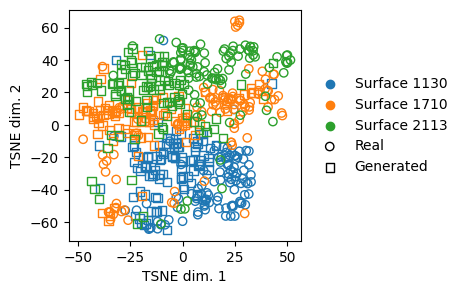

In [314]:
### perform tsne on morphological descriptors and make similar histograms

# specify on which columns to perform:
keywords_to_keep = ['AreaShape', 'Intensity']
keywords_to_exclude = ['Location']
chips = ['Chip_1130_1', 'Chip_1710_1', 'Chip_2113_1']
n_pca_components=50  
max_points = 100
# chips = list(
#     pd.Series(list(map(lambda x: x[:-5], full_df['Metadata_Chip_actin'].unique()))).unique()
# )
# print(chips)

def plot_tsne(df, chips, keywords_to_keep=('AreaShape', 'Intensity'),
                              keywords_to_exclude = ('Location',),
                              sources=('real', 'fake'), 
                              colors=tuple(matplotlib.colors.TABLEAU_COLORS.keys()),
                              markers=('o','s', '8', 'D', '*', 'P', 'H','s', 'X',),
                          n_pca_components=25,  # used for reducing the dimensionality of the data to speed up tsne and since there is a lot of corelation between some features
                          labels=None, max_points=np.inf, ax=None,
                              **tsne_params
                             ):
    
    if ax is None:
        fig, ax = plt.subplots()
    # only keep the relevant chips:
    df = df[df['Metadata_Chip_dapi'].str.contains('|'.join(chips))]
    
    cols_to_keep = [
        col for col in df.columns 
        if (any(kw in col for kw in keywords_to_keep)
            and not any(kw in col for kw in keywords_to_exclude)
           )
    ]
    df_temp = df[cols_to_keep].apply(pd.to_numeric, errors='coerce')
    df_temp = df_temp.dropna(axis=1)
    


    # z-normalization to discard scale information of the features:
    df_temp = (df_temp - np.mean(df_temp, axis=0)) / (np.std(df_temp, axis=0, ) + 1e-6)
    
    pca = PCA(n_components=n_pca_components)
    low_dim = pca.fit_transform(df_temp)
    tsne = TSNE(n_jobs=-1, **tsne_params)
    low_dim = tsne.fit_transform(low_dim)
    

    
    # iterate over chips and sources. plot chips in different colors and sources in the markers:

    for i, chip in enumerate(chips):
        color = colors[i]
        label = 'Surface ' + chip.split('_')[1]
        p_legend = plt.scatter([], [], edgecolors=color, facecolors=color, marker='o', label=label)

        for j, source in enumerate(sources):
            mask = df['Metadata_Chip_dapi'] == chip + '_' + source
            to_plot_this = low_dim[mask]
            if len(to_plot_this) > max_points:
                random_idx = np.random.choice(np.arange(len(to_plot_this)), replace=False, size=max_points)
                to_plot_this = to_plot_this[random_idx]
            marker = None if markers is None else markers[j]
            
            p = plt.scatter(to_plot_this[:,0], to_plot_this[:,1], edgecolors=color, facecolors='none',
                           marker=marker, alpha=1,
#                             label=label if j == 0 else None
                           )
            if i == len(chips)-1:
                # empty scatter for legend
                label= source.capitalize() if source.lower() != 'fake' else 'Generated'
                p_legend = plt.scatter([], [], edgecolors='black', facecolors='none', marker=marker, alpha=1,
                                       label=label)

    plt.legend(bbox_to_anchor=(1.01, 0.5), loc='center left', ncol=1, frameon=False)

fig, ax = plt.subplots(figsize=(3, 3))
plot_tsne(full_df, chips, keywords_to_keep, keywords_to_exclude, n_pca_components=n_pca_components, max_points=max_points,
          ax=ax)
plt.xlabel('TSNE dim. 1')
plt.ylabel('TSNE dim. 2')
plt.savefig(os.path.join(spath, 'tsne.svg'), bbox_inches='tight', transparent=True)

plt.show()

In [209]:
# ## change here the chips and features you want to plot the distribution of, as well a hist_kwargs
# # hist_kwargs can contain cumulative: bool, as well as any kwargs accepted by np.histogram

# feats = ['Intensity_IntegratedIntensity_YAP_yap_nucleus_div_cyto'] #['Intensity_MeanIntensity_CorrYAP_yap_nucleus', 'Intensity_MeanIntensity_CorrYAP_yap_cyto']
# chips = ['Chip_1130_1', 'Chip_1710_1', 'Chip_2113_1']
# chips = list(
#     pd.Series(list(map(lambda x: x[:-5], full_df['Metadata_Chip_actin'].unique()))).unique()
# )
# hist_kwargs=dict(density=True, bins=150, cumulative=False, use_kde=True)

# # start making the plot
# fig, axs = plt.subplots(ncols=len(feats), nrows=len(chips), squeeze=False, figsize=(5*len(feats), 5*(len(chips))),
#                        sharex='col', sharey='col')

# df_yap = full_df[~np.isnan(pd.to_numeric(full_df['Intensity_IntegratedIntensity_YAP_yap_nucleus_div_cyto']))]
# df_yap = df_yap[df_yap['Intensity_IntegratedIntensity_YAP_yap_nucleus_div_cyto'] <= np.quantile(df_yap['Intensity_IntegratedIntensity_YAP_yap_nucleus_div_cyto'], 0.975)]

# make_histograms(df_yap, chips, feats, axs, hist_kwargs=hist_kwargs)

# # for ax in axs.flat:
# #     ax.set_yscale('log')


# plt.show()

# violin plots:

In [210]:
def make_violin_plot(data, feature, chips=None, ax=None):
    df_subset = full_df[['Metadata_Chip_dapi', feature]].copy()
    df_subset = df_subset[df_subset['Metadata_Chip_dapi'].isin(chips)] if chips is not None else df_subset
    df_subset[feature] = pd.to_numeric(df_subset[feature])
    sns.violinplot(data=df_subset, x='Metadata_Chip_dapi', y=feature, ax=ax)
    plt.xticks(rotation=90)
    return
    

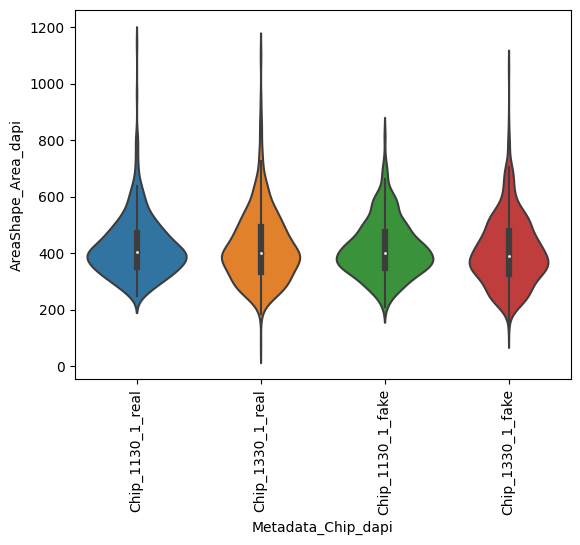

In [211]:
# example:

feature = 'AreaShape_Area_dapi'
chips = ['Chip_1130_1_real', 'Chip_1130_1_fake', 'Chip_1330_1_real', 'Chip_1330_1_fake']
make_violin_plot(full_df, feature, chips)


plt.show()

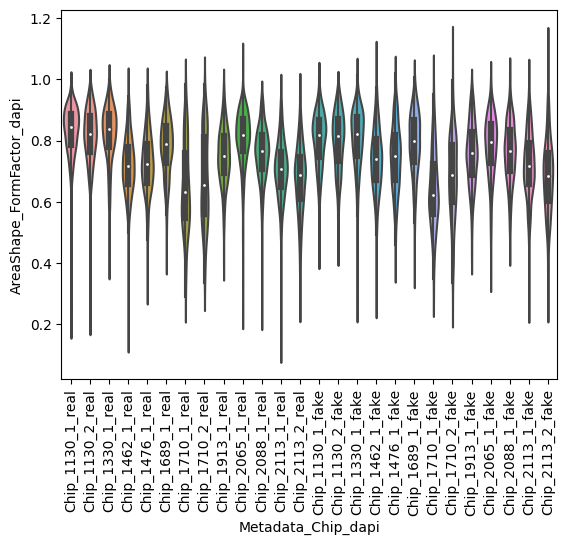

In [212]:
feature = 'AreaShape_FormFactor_dapi'
make_violin_plot(full_df, feature)


plt.show()

 # plot the correlation between cellular variables:

In [213]:
def make_bio_corr_plot(data, feature_x, feature_y, num_bins, min_count=0, sources=('real', 'fake'), 
                       colors=None,
                        markers=None,
                       chips=None,
                       uncertainty_calc=lambda x: np.std(x), ax=None, markevery=4):
    """
    data: df with all columns of interest
    feature_x: feature for x axis
    feature_y: feature for y axis
    num_bins: number of bins to group the feature_x by -- mean and std are calculated and plotted for each bin
    min_count: minimum number of samples per bin to make it into the plot
    sources: ['real', 'fake'] or subset thereof to show real/fake images
    chips: None to work on all chips, list of chips to include only those chips in the plot
    uncertainty_calc: function that calculates the spread for the shaded area (default = std)
    ax: matplotlib axis or None

    """
    if ax is None:
        fig, ax = plt.subplots()
    
    if chips is not None:
        chips = [c + '_' + s for c in chips for s in sources]
        data = data[data['Metadata_Chip_dapi'].isin(chips)].copy()
    
    try:
        df_for_plot = data[['Metadata_Source_dapi', feature_x, feature_y]].apply(pd.to_numeric, errors='ignore')
    except:
        df_for_plot = data
        
    def upper(x): return np.mean(x) + uncertainty_calc(x)
    def lower(x): return np.mean(x) - uncertainty_calc(x)
    
    all_groupeds = []
    for i, source in enumerate(sources):
        df_temp = df_for_plot[df_for_plot['Metadata_Source'].str.contains(source)].copy()

        # now make a plot of solidity on x-axis and yap in nucleus on y-axis:

        bins = pd.cut(df_temp[feature_x], bins=num_bins)
        df_temp['feat_bin'] = bins
        grouped = df_temp[['feat_bin', feature_y]].groupby('feat_bin')[feature_y]
        grouped = grouped.agg(['mean', upper, lower, 'count']).dropna()
        all_groupeds.append(grouped)
        grouped = grouped[grouped['count'] >= min_count]
        lab = source.capitalize() if source == 'real' else 'Generated'

        p = ax.plot(pd.IntervalIndex(grouped.index).mid.values, grouped['mean'].values, color=colors[i] if colors is not None else None,
                  marker=markers[i] if markers is not None else None, markersize=7, markevery=markevery,
                  markerfacecolor='none',markeredgewidth=1.5,
                  label=lab,
                  linewidth=2, linestyle='-')
        col = p[0].get_color()
        ax.fill_between(pd.IntervalIndex(grouped.index).mid.values,
                            grouped['lower'].values,
                            grouped['upper'].values,
                            color=col, # same color as the line,
                            alpha=0.3,
                            linewidth=3, linestyle='-', )
    lab_x = feature_x.split('_')[2].capitalize() + ' ' + feature_x.split('_')[1].capitalize()
    lab_y = feature_y.split('_')[2].capitalize() + ' ' + feature_y.split('_')[1].capitalize()
    ax.set_xlabel(lab_x)
    ax.set_ylabel(lab_y)
    return all_groupeds

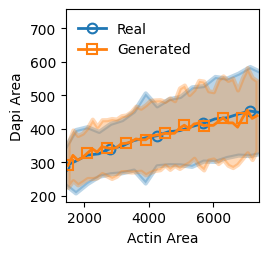

In [214]:
#example: Area of actin vs area of dapi:

fig, ax = plt.subplots(figsize=(2.5, 2.5))
min_count = 50
all_groupeds = make_bio_corr_plot(full_df, feature_x='AreaShape_Area_actin', feature_y='AreaShape_Area_dapi', 
                                  markers=('o', 's'),
                                  num_bins=250,
                                  min_count=min_count, ax=ax, 
                                #   uncertainty_calc=lambda x: 3*np.std(x) / np.sqrt(len(x))
                                  )

x_low = max([pd.IntervalIndex(g[g['count'] > min_count].index).left.min() for g in all_groupeds])
x_high = min([pd.IntervalIndex(g[g['count'] > min_count].index).right.max() for g in all_groupeds])
plt.xlim(x_low, x_high)
plt.legend(frameon=False, loc='upper left')

plt.savefig(os.path.join(spath, 'bio_corr_area_actin_area_dapi.svg'), bbox_inches='tight', transparent=True)

plt.show()

# or, only for certain surfaces:

# make_bio_corr_plot(full_df, feature_x='AreaShape_Area_actin', feature_y='AreaShape_Area_dapi', num_bins=50,
#                   min_count=10, chips=['Chip_1476_1'])

# plt.show()


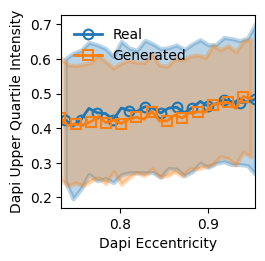

In [215]:
# dapi pixel intensity vs shape of the nucleus:
# suggestion by Jan was median but this does not give such an interesting plot, instead I used max

fig, ax = plt.subplots(figsize=(2.5, 2.5))
min_count = 100
all_groupeds = make_bio_corr_plot(full_df, feature_x='AreaShape_Eccentricity_dapi', 
                                  feature_y='Intensity_UpperQuartileIntensity_DNA_dapi', 
                                  markers=('o', 's'),
                                  num_bins=100,
                                  min_count=min_count, ax=ax, markevery=2)

x_low = max([pd.IntervalIndex(g[g['count'] > min_count].index).left.min() for g in all_groupeds])
x_high = min([pd.IntervalIndex(g[g['count'] > min_count].index).right.max() for g in all_groupeds])
plt.xlim(x_low, x_high)
plt.legend(frameon=False, loc='upper left'  #ncol=2
           )
plt.ylabel('Dapi Upper Quartile Intensity')

plt.savefig(os.path.join(spath, 'bio_corr_ecc_dapi_UQIntens_dapi.svg'), bbox_inches='tight', transparent=True)

plt.show()

# # or, only for certain surfaces:

# # make_bio_corr_plot(full_df, feature_x='AreaShape_Area_actin', feature_y='AreaShape_Area_dapi', num_bins=50,
# #                   min_count=10, chips=['Chip_1476_1'])

# # plt.show()


# make_bio_corr_plot(full_df, feature_x='AreaShape_Eccentricity_dapi', 
#                    feature_y='Intensity_UpperQuartileIntensity_DNA_dapi',
#                    num_bins=50,
#                   min_count=150, 
#                   uncertainty_calc=lambda x: 3*np.std(x) / np.sqrt(len(x))
#                   )
# plt.legend()
# plt.show()

In [216]:
full_df.columns[full_df.columns.str.contains('Intensity_DNA_dapi')]

Index(['Intensity_IntegratedIntensity_DNA_dapi',
       'Intensity_LowerQuartileIntensity_DNA_dapi',
       'Intensity_MADIntensity_DNA_dapi', 'Intensity_MaxIntensity_DNA_dapi',
       'Intensity_MeanIntensity_DNA_dapi',
       'Intensity_MedianIntensity_DNA_dapi', 'Intensity_MinIntensity_DNA_dapi',
       'Intensity_StdIntensity_DNA_dapi',
       'Intensity_UpperQuartileIntensity_DNA_dapi'],
      dtype='object')

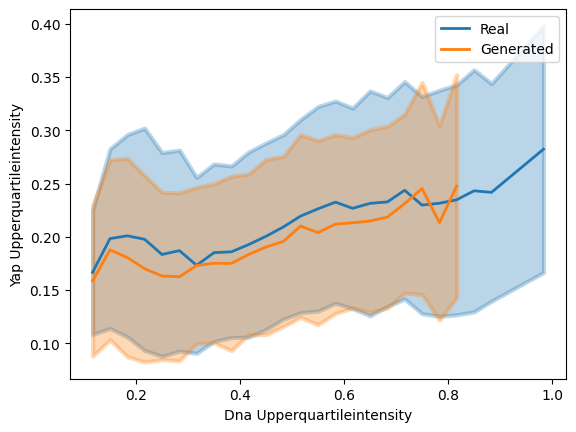

In [217]:
# dapi pixel intensity vs shape of the nucleus:
# suggestion by Jan was median but this does not give such an interesting plot, instead I used max



make_bio_corr_plot(full_df, feature_x='Intensity_UpperQuartileIntensity_DNA_dapi',
                   feature_y='Intensity_UpperQuartileIntensity_YAP_yap_nucleus',
                   num_bins=30,
                  min_count=50, 
                   #uncertainty_calc=lambda x: 3*np.std(x) / np.sqrt(len(x))
                  )
plt.legend()
plt.show()

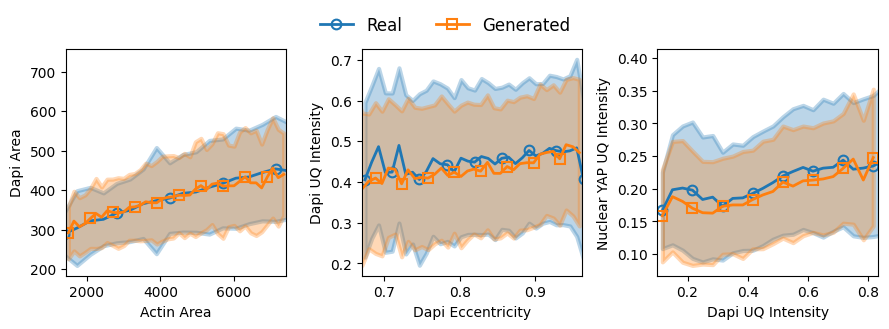

In [218]:
min_count = 50
feats_x = ['AreaShape_Area_actin', 'AreaShape_Eccentricity_dapi', 'Intensity_UpperQuartileIntensity_DNA_dapi']
feats_y = ['AreaShape_Area_dapi', 'Intensity_UpperQuartileIntensity_DNA_dapi', 'Intensity_UpperQuartileIntensity_YAP_yap_nucleus']
num_bins = [250, 100, 30]
markevery = [4, 4, 3]
xlabs = ['Actin Area', 'Dapi Eccentricity', 'Dapi UQ Intensity']
ylabs = ['Dapi Area', 'Dapi UQ Intensity', 'Nuclear YAP UQ Intensity']

fig, ax = plt.subplots(ncols=len(feats_x), figsize=(3*len(feats_x), 3))

for i, feat_x in enumerate(feats_x):
    all_groupeds = make_bio_corr_plot(full_df, feature_x=feat_x, feature_y=feats_y[i], num_bins=num_bins[i],
                       min_count=min_count, ax=ax[i], markevery=markevery[i],
                       colors=('tab:blue', 'tab:orange'),
                       markers=('o', 's'),
                       )
    # ax[i].set_title(feat_x.split('_')[2].capitalize() + ' ' + feat_x.split('_')[1].capitalize())
    x_low = max([pd.IntervalIndex(g[g['count'] > min_count].index).left.min() for g in all_groupeds])
    x_high = min([pd.IntervalIndex(g[g['count'] > min_count].index).right.max() for g in all_groupeds])
    ax[i].set_xlim(x_low, x_high)
    ax[i].set_xlabel(xlabs[i])
    ax[i].set_ylabel(ylabs[i])

fig = ax[0].figure
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.95))
fig.tight_layout()
plt.savefig(os.path.join(spath, 'bio_corr_feats-1-3.svg'), bbox_inches='tight', transparent=True)
plt.show()


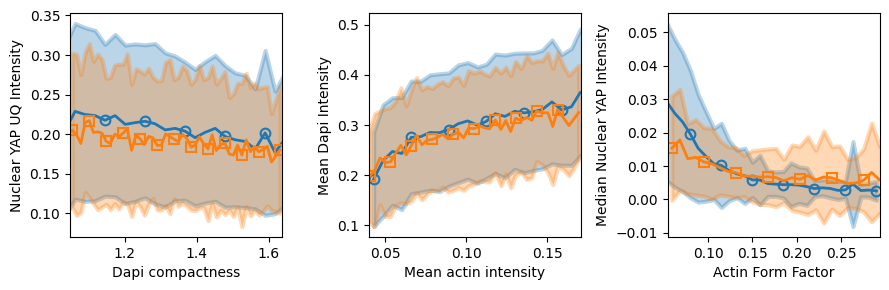

In [219]:
feats_x = ['AreaShape_Compactness_dapi', 'Intensity_MeanIntensity_CellBody_actin', 'AreaShape_FormFactor_actin']
feats_y = ['Intensity_UpperQuartileIntensity_YAP_yap_nucleus', 'Intensity_MeanIntensity_DNA_dapi','Intensity_MedianIntensity_CorrYAP_yap_nucleus']
num_bins = [250, 100, 100]
markevery = [4, 4, 4]
xlabs = ['Dapi compactness', 'Mean actin intensity', 'Actin Form Factor']
ylabs = ['Nuclear YAP UQ Intensity', 'Mean Dapi Intensity', 'Median Nuclear YAP Intensity']

fig, ax = plt.subplots(ncols=len(feats_x), figsize=(3*len(feats_x), 3))

for i, feat_x in enumerate(feats_x):
    all_groupeds = make_bio_corr_plot(full_df, feature_x=feat_x, feature_y=feats_y[i], num_bins=num_bins[i],
                       min_count=min_count, ax=ax[i], markevery=markevery[i],
                       colors=('tab:blue', 'tab:orange'),
                       markers=('o', 's'),
                       )
    # ax[i].set_title(feat_x.split('_')[2].capitalize() + ' ' + feat_x.split('_')[1].capitalize())
    x_low = max([pd.IntervalIndex(g[g['count'] > min_count].index).left.min() for g in all_groupeds])
    x_high = min([pd.IntervalIndex(g[g['count'] > min_count].index).right.max() for g in all_groupeds])
    ax[i].set_xlim(x_low, x_high)
    ax[i].set_xlabel(xlabs[i])
    ax[i].set_ylabel(ylabs[i])

fig = ax[0].figure
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.95))
fig.tight_layout()
plt.savefig(os.path.join(spath, 'bio_corr_feats-4-6.svg'), bbox_inches='tight', transparent=True)
plt.show()


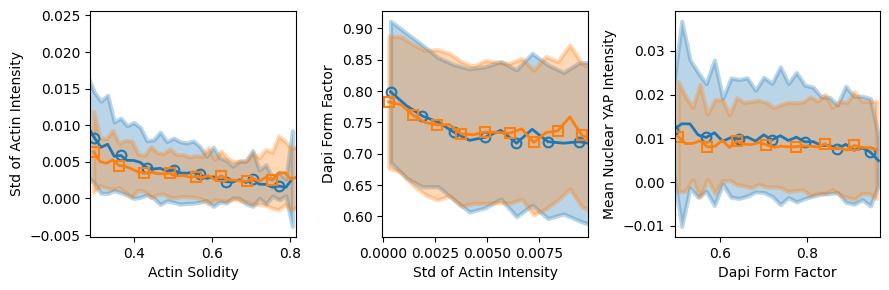

In [220]:
feats_x = ['AreaShape_Solidity_actin', 'Intensity_StdIntensity_CorrCellBody_actin', 'AreaShape_FormFactor_dapi']
feats_y = ['Intensity_StdIntensity_CorrCellBody_actin', 'AreaShape_FormFactor_dapi', 'Intensity_MeanIntensity_CorrYAP_yap_nucleus']
num_bins = [50, 75, 50]
markevery = [4, 2, 4]
xlabs = ['Actin Solidity', 'Std of Actin Intensity', 'Dapi Form Factor']
ylabs = ['Std of Actin Intensity', 'Dapi Form Factor', 'Mean Nuclear YAP Intensity']

fig, ax = plt.subplots(ncols=len(feats_x), figsize=(3*len(feats_x), 3))

for i, feat_x in enumerate(feats_x):
    all_groupeds = make_bio_corr_plot(full_df, feature_x=feat_x, feature_y=feats_y[i], num_bins=num_bins[i],
                       min_count=min_count, ax=ax[i], markevery=markevery[i],
                       colors=('tab:blue', 'tab:orange'),
                       markers=('o', 's'),
                       )
    # ax[i].set_title(feat_x.split('_')[2].capitalize() + ' ' + feat_x.split('_')[1].capitalize())
    x_low = max([pd.IntervalIndex(g[g['count'] > min_count].index).left.min() for g in all_groupeds])
    x_high = min([pd.IntervalIndex(g[g['count'] > min_count].index).right.max() for g in all_groupeds])
    ax[i].set_xlim(x_low, x_high)
    ax[i].set_xlabel(xlabs[i])
    ax[i].set_ylabel(ylabs[i])

fig = ax[0].figure
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.95))
fig.tight_layout()
plt.savefig(os.path.join(spath, 'bio_corr_feats-7-9.svg'), bbox_inches='tight', transparent=True)
plt.show()


In [221]:
subdf = full_df[['AreaShape_Eccentricity_dapi', 'Intensity_UpperQuartileIntensity_YAP_yap_nucleus', 'Intensity_UpperQuartileIntensity_DNA_dapi']]
subdf.corr()

,AreaShape_Eccentricity_dapi,Intensity_UpperQuartileIntensity_YAP_yap_nucleus,Intensity_UpperQuartileIntensity_DNA_dapi
AreaShape_Eccentricity_dapi,1.000000,-0.069243,0.085992
Intensity_UpperQuartileIntensity_YAP_yap_nucleus,-0.069243,1.000000,0.231367
Intensity_UpperQuartileIntensity_DNA_dapi,0.085992,0.231367,1.000000


In [222]:

corrs = full_df[full_df['Metadata_Chip_dapi'].str.contains('real')].apply(
    pd.to_numeric, errors='coerce'
    ).fillna(value=full_df).corr(numeric_only=True, method='spearman', )

In [223]:
strongest = corrs.abs().unstack().sort_values()[(~corrs.abs().unstack().sort_values().isna()) & (corrs.abs().unstack().sort_values() < 0.9)]
strongest.tail(30)

Texture_SumVariance_CorrDNA_3_03_256_actin            Intensity_StdIntensity_CorrDNA_dapi                     0.899252
                                                      Intensity_StdIntensity_DNA_dapi                         0.899252
Intensity_IntegratedIntensity_CorrYAP_actin           Intensity_IntegratedIntensityEdge_CorrCellBody_actin    0.899281
Intensity_IntegratedIntensityEdge_CorrCellBody_actin  Intensity_IntegratedIntensity_CorrYAP_actin             0.899281
Intensity_UpperQuartileIntensity_CorrCellBody_actin   Texture_InfoMeas2_CorrCellBody_3_03_256_dapi            0.899307
Texture_InfoMeas2_CorrCellBody_3_03_256_dapi          Intensity_UpperQuartileIntensity_CorrCellBody_actin     0.899307
Texture_InfoMeas1_CorrCellBody_3_01_256_dapi          Texture_Entropy_CorrCellBody_3_01_256_dapi              0.899413
Texture_Entropy_CorrCellBody_3_01_256_dapi            Texture_InfoMeas1_CorrCellBody_3_01_256_dapi            0.899413
Texture_DifferenceEntropy_CorrDNA_3_02_256_actin

In [224]:
y_feat = 'Intensity_MedianIntensity_CorrYAP_yap_nucleus'
corrs_y_feat = corrs[corrs.columns.str.contains(y_feat)].T[y_feat].sort_values()
corrs_y_feat = corrs_y_feat[~corrs_y_feat.isna()]
corrs_y_feat = corrs_y_feat[~(
    corrs_y_feat.index.str.contains('Intensity_YAP') | 
    corrs_y_feat.index.str.contains('IntensityEdge_YAP') |
    corrs_y_feat.index.str.contains('Intensity_CorrYAP') |
    corrs_y_feat.index.str.contains('IntensityEdge_CorrYAP') 
) ]
corrs_y_feat.head(20)

Texture_InfoMeas1_CorrCellBody_3_03_256_dapi                  -0.736361
Texture_InfoMeas1_CorrCellBody_3_01_256_dapi                  -0.719914
Texture_InfoMeas1_CorrCellBody_3_02_256_dapi                  -0.697924
Texture_InfoMeas1_CorrCellBody_3_00_256_dapi                  -0.650057
AreaShape_FormFactor_actin                                    -0.624500
AreaShape_Extent_actin                                        -0.587842
Texture_DifferenceVariance_CorrCellBody_3_00_256_actin        -0.515667
Texture_AngularSecondMoment_CorrCellBody_3_00_256_actin       -0.513510
Texture_InverseDifferenceMoment_CorrCellBody_3_00_256_actin   -0.511629
AreaShape_BoundingBoxMinimum_X_actin                          -0.511151
Texture_DifferenceVariance_CorrCellBody_3_01_256_actin        -0.507358
Texture_AngularSecondMoment_CorrCellBody_3_01_256_actin       -0.507203
Texture_DifferenceVariance_CorrCellBody_3_02_256_actin        -0.506448
Texture_AngularSecondMoment_CorrCellBody_3_02_256_actin       -0

In [225]:
y_feat = 'Intensity_StdIntensity_CorrCellBody_actin'
corrs_y_feat = corrs[corrs.columns.str.contains(y_feat)].T[y_feat].sort_values()
corrs_y_feat = corrs_y_feat[~corrs_y_feat.isna()]
# corrs_y_feat = corrs_y_feat[~(
#     corrs_y_feat.index.str.contains('Intensity_CellBody') | 
#     corrs_y_feat.index.str.contains('IntensityEdge_CellBody') |
#     corrs_y_feat.index.str.contains('Intensity_CorrCellBody') |
#     corrs_y_feat.index.str.contains('IntensityEdge_CorrCellBody') 
# ) ]
corrs_y_feat = corrs_y_feat[corrs_y_feat.index.str.contains('Shape')]
corrs_y_feat

AreaShape_FormFactor_actin             -0.649229
AreaShape_Extent_actin                 -0.586783
AreaShape_BoundingBoxMinimum_X_actin   -0.585920
AreaShape_Zernike_0_0_actin            -0.547388
AreaShape_Zernike_2_2_actin            -0.510782
                                          ...   
AreaShape_Compactness_actin             0.649229
AreaShape_Perimeter_actin               0.694217
AreaShape_MajorAxisLength_actin         0.726337
AreaShape_BoundingBoxArea_actin         0.744131
AreaShape_MaxFeretDiameter_actin        0.746682
Name: Intensity_StdIntensity_CorrCellBody_actin, Length: 108, dtype: float64

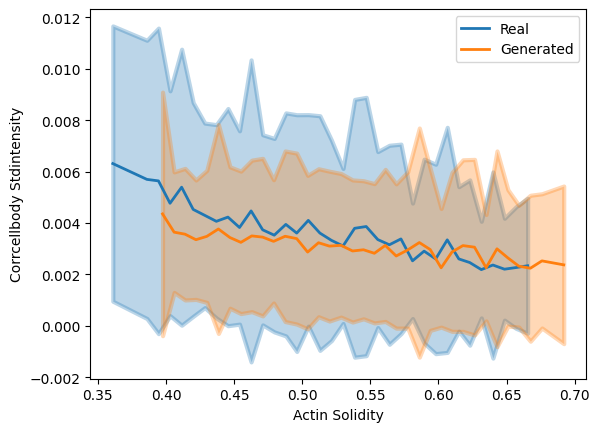

In [226]:
make_bio_corr_plot(full_df, feature_x='AreaShape_Solidity_actin', feature_y='Intensity_StdIntensity_CorrCellBody_actin',
                   num_bins=100,
                  min_count=100, 
                  uncertainty_calc=lambda x: np.std(x)
                  )
plt.legend()
# plt.xlim(0.075, 0.225)
plt.show()

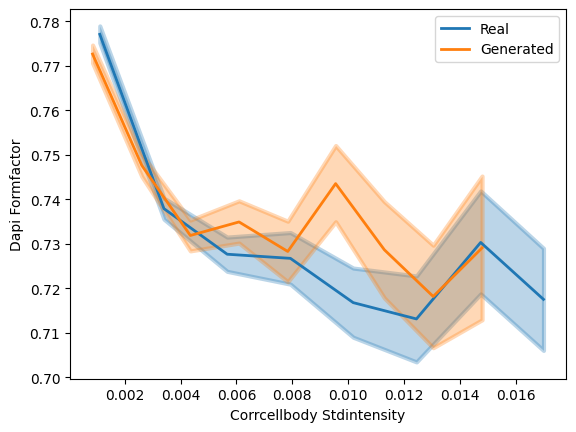

In [227]:
make_bio_corr_plot(full_df, feature_x='Intensity_StdIntensity_CorrCellBody_actin', feature_y='AreaShape_FormFactor_dapi',
                   num_bins=25,
                  min_count=50, 
                  uncertainty_calc=lambda x: np.std(x) / np.sqrt(len(x))
                  )
plt.legend()
# plt.xlim(0.075, 0.225)
plt.show()

# correlation of the biological fingerprint of the chip


In [228]:
cmap = matplotlib.colormaps['viridis']

def get_means(df, chips, feats, sources=('real', 'fake')):
    means =  []

    for k, source in enumerate(sources):
        means_this_source = []  # means per source (real/fake)
        for c, chip in enumerate(chips):
            means_this_source_chip = []
            for j, feat in enumerate(feats):
                data = df[df['Metadata_Chip_dapi'] == chip + '_' + source][feat]
                m = np.mean(data)
                means_this_source_chip.append(m)
            means_this_source.append(means_this_source_chip)
        means.append(means_this_source)
    
    # array of shape (len(sources), len(chips), len(feats)) which contains the mean per source for all feats for this chip
    means = np.array(means) 
    return means

def make_heatmap(arr, feats, chips, arr_labels=None, cmap='viridis'):

    im = ax.imshow(arr, cmap=cmap)
    ax.set_xticks(np.arange(len(feats)))
    ax.set_xticklabels([feat.split('_')[1] for feat in feats], rotation=45, ha='right')

    ax.set_yticks(np.arange(len(chips)))
    ax.set_yticklabels(chips)

    
    lab_arr = arr if arr_labels is None else arr_labels
    lab_arr = np.round(lab_arr, 3)
    
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            text = ax.text(j, i, lab_arr[i,j], ha='center', va='center', color='w', fontsize=8)
            text.set_path_effects([withStroke(linewidth=2, foreground='gray')])  # Adds a shadow effect
    

C:\Users\s161975\AppData\Local\Temp\ipykernel_25648\1411526119.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


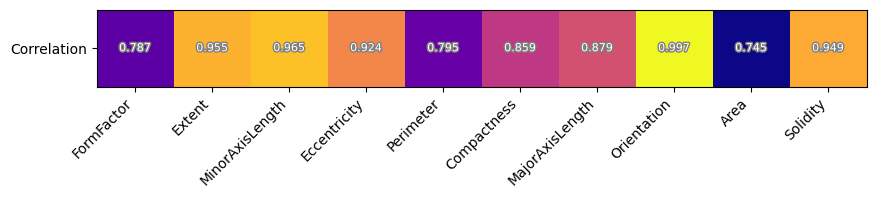

In [229]:
# get all the unique chips:
chips = list(
    pd.Series(list(map(lambda x: x[:-5], full_df['Metadata_Chip_actin'].unique()))).unique()
)

# feats to consider:

feats = ['AreaShape_FormFactor_actin', 'AreaShape_Extent_actin','AreaShape_MinorAxisLength_actin',
         'AreaShape_Eccentricity_actin',  'AreaShape_Perimeter_actin', 'AreaShape_Compactness_actin', 
         'AreaShape_MajorAxisLength_actin', 'AreaShape_Orientation_actin',
         'AreaShape_Area_actin','AreaShape_Solidity_actin',
        ]

means = get_means(full_df, chips, feats)  # shape sources, chips, feats


# correlation of the fingerprint per chip through row-wise Pearson correlation
corrs = np.array([pearsonr(row1, row2)[0] for row1, row2 in zip(means[0].T, means[1].T)])[None,:]
fig, ax = plt.subplots(figsize=(15, 1))
make_heatmap(corrs, feats, ['Correlation'], cmap='plasma')
plt.tight_layout()
plt.savefig(os.path.join(spath, 'corr_fingerprint_clean.svg'), transparent=True, bbox_inches='tight')
plt.show()


# plot cell locations, grouped by source and/or feature quantiles

In [300]:
def load_imgs(source_fold, chip, filter_kwds=None, num=1):
    images = os.listdir(os.path.join(source_fold, chip))
    filtered_images = list(filter(lambda x: all([f_kw.lower() in x.lower() for f_kw in filter_kwds]),
                            images))
    if num is not None:
        num = min(num, len(filtered_images))
        ims_out = np.random.choice(filtered_images, size=num, replace=False)
    else:
        ims_out = filtered_images
    ims = [np.array(Image.open(os.path.join(source_fold, chip, im))) for im in ims_out]
    return ims

def plot_cell_locs(df, chip, path_real_imgs,
                   source, 
                   feat_x='AreaShape_Center_X_dapi', 
                   feat_y='AreaShape_Center_Y_dapi',
                   markers=('v', 'h'),
                   colors=('tab:blue', 'tab:orange'),
                   filter_feat=None,
                   filter_feat_quantiles=None,
                   ax=None,
                   zoom_pixels=None,
                   max_points=np.inf
                  ):
    
    
    if filter_feat is not None:
        # sanity check:
        assert len(filter_feat_quantiles) == 2, 'expected a tuple defining high/low quantiles!'        
    
    if ax is None:
        fig, ax = plt.subplots()
    
    data_this = df[df['Metadata_Chip_dapi'] == chip + '_' + source]
    # plot background:
    bg = load_imgs(path_real_imgs, chip + '_real', ['background'])[0]
    # if we're zooming, we need to crop the backgrounnd with zoom_pixels from the center:
    if zoom_pixels is not None:
        c = bg.shape[0] // 2
        left = low = c - zoom_pixels//2
        right = high = c + zoom_pixels//2
    else:
        left = low = 0
        high = bg.shape[0]
        right = bg.shape[1]
        
    ax.imshow(bg[low:high, left:right], cmap='gray', origin='lower')

    # if necessary, keep only lowest, highest part of data by filter_feat
    
    if filter_feat is not None:
        data_this[filter_feat] = pd.to_numeric(data_this[filter_feat])
        q_low, q_high = np.quantile(data_this[filter_feat], q=filter_feat_quantiles)
        data_low = data_this[data_this[filter_feat] <= q_low]
        data_high = data_this[data_this[filter_feat] >= q_high]
        datas = [data_low, data_high]
        label_prefixs = ['Low', 'High']  
    else:
        datas = [data_this]
        label_prefixs = ['']
        
    for i, data in enumerate(datas):
            # make scatter on bg, adjusted for any possible zooming:
            data[feat_x] = data[feat_x] - left
            data[feat_y] = data[feat_y] - low
            
            mask = (data[feat_x] >= 0) & (data[feat_x] <= zoom_pixels) & (data[feat_y] >= 0) & (data[feat_y] <= zoom_pixels)
            x = data[feat_x][mask].values
            y = data[feat_y][mask].values
            if len(x) > max_points:
                random_idx = np.random.choice(np.arange(len(x)), size=max_points, replace=False)
                x = x[random_idx]
                y = y[random_idx]
                
            
            ax.scatter(x, y,
               marker=markers[i], facecolor='none', edgecolor=colors[i], linewidth=1.5,
               label=f"{label_prefixs[i]} {filter_feat.split('_')[1]}",
               alpha=0.6, s=20)

    

C:\Users\s161975\AppData\Local\Temp\ipykernel_25648\2503875707.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_this[filter_feat] = pd.to_numeric(data_this[filter_feat])
C:\Users\s161975\AppData\Local\Temp\ipykernel_25648\2503875707.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[feat_x] = data[feat_x] - left
C:\Users\s161975\AppData\Local\Temp\ipykernel_25648\2503875707.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

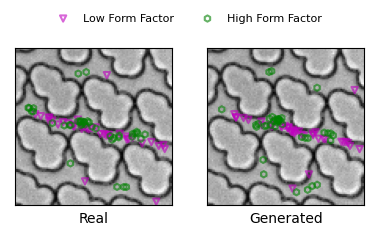

In [315]:
# get all the unique chips: #list(pd.Series(list(map(lambda x: x[:-5], full_df['Metadata_Chip_actin'].unique()))).unique())
chips =  ['Chip_1476_1']

path_real_imgs = 'real_images_29-4-25_insert_preproc'
sources = ['real', 'fake']
# define features and quantiles so that we only plot the low/high features
filter_feat = 'AreaShape_FormFactor_dapi'
filter_feat_quantiles = (0.2, 0.8)
zoom_pixels = 100
max_points = 40

ncols = 2
fig, axs = plt.subplots(ncols=ncols, nrows=1, figsize=(4.0, 2.))

i = 0
for chip in chips:
    for source in sources:
        ax = axs.flat[i]
        plot_cell_locs(full_df, chip, path_real_imgs, source=source,
                       filter_feat=filter_feat, filter_feat_quantiles=filter_feat_quantiles,
                       ax=ax, colors=('m', 'green'), zoom_pixels=zoom_pixels, max_points=max_points
                      )
        source = sources[i % len(sources)].capitalize()
        ax.set_xlabel(source if source.lower() != 'fake' else 'Generated')

        i += 1

    

# aesthetics:
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])

# take care of the legend:
handles, labels = axs.flat[0].get_legend_handles_labels()
labels = ['Low Form Factor', 'High Form Factor'] if filter_feat is not None else labels
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout()
plt.savefig(os.path.join(spath, f'cell_locs_form_factor_dapi_1476.svg'), bbox_inches='tight', transparent=True)
plt.show()

C:\Users\s161975\AppData\Local\Temp\ipykernel_25648\2503875707.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_this[filter_feat] = pd.to_numeric(data_this[filter_feat])
C:\Users\s161975\AppData\Local\Temp\ipykernel_25648\2503875707.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[feat_x] = data[feat_x] - left
C:\Users\s161975\AppData\Local\Temp\ipykernel_25648\2503875707.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

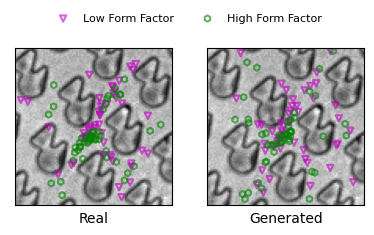

In [316]:
# get all the unique chips: #list(pd.Series(list(map(lambda x: x[:-5], full_df['Metadata_Chip_actin'].unique()))).unique())
chips =  ['Chip_1689_1']

path_real_imgs = 'real_images_29-4-25_insert_preproc'
sources = ['real', 'fake']
# define features and quantiles so that we only plot the low/high features
filter_feat = 'AreaShape_FormFactor_dapi'
filter_feat_quantiles = (0.2, 0.8)
zoom_pixels = 100
max_points = 50

ncols = 2
fig, axs = plt.subplots(ncols=ncols, nrows=1, figsize=(4.0, 2.))

i = 0
for chip in chips:
    for source in sources:
        ax = axs.flat[i]
        plot_cell_locs(full_df, chip, path_real_imgs, source=source,
                       filter_feat=filter_feat, filter_feat_quantiles=filter_feat_quantiles,
                       ax=ax, colors=('m', 'green'), zoom_pixels=zoom_pixels, max_points=max_points
                      )
        source = sources[i % len(sources)].capitalize()
        ax.set_xlabel(source if source.lower() != 'fake' else 'Generated')

        i += 1

    

# aesthetics:
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])

# take care of the legend:
handles, labels = axs.flat[0].get_legend_handles_labels()
labels = ['Low Form Factor', 'High Form Factor'] if filter_feat is not None else labels
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout()
plt.savefig(os.path.join(spath, 'cell_locs_form_factor_dapi_1689.svg'), bbox_inches='tight', transparent=True)
plt.show()